# 💰 Usecase 2: FinOps, Token Economics & Latency Leaderboards

This notebook implements comprehensive FinOps and performance analytics by directly querying the 24 flat SQL views (`v_llm_response`, `v_tool_completed`, etc.) and raw table (`agent_events`) in BigQuery dataset `nikunjbhartia-test-clients.agent_analytics`.

### Key Derived Metrics & Capabilities:
- **LLM Token Economics**: Prompt tokens, candidate tokens, total calls, and cost attribution per model (`gemini-2.5-flash`, etc.).
- **Universal Tool Leaderboards**: Execution counts, average latency, and max latency per tool across team agents.
- **Session Health Scorecard**: Reliability percentages and error counts per session.
- **Visual Analytics**: Interactive Matplotlib & Seaborn charts for Event Type distribution and Token Breakdown.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.auth import default
from google.cloud import bigquery

sns.set_theme(style="whitegrid")
credentials, _ = default()
PROJECT_ID = "nikunjbhartia-test-clients"
DATASET_ID = "agent_analytics"
TABLE_ID = "agent_events"

bq_client = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print(f"✅ Connected to BigQuery dataset `{PROJECT_ID}.{DATASET_ID}`")


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✅ Connected to BigQuery dataset `nikunjbhartia-test-clients.agent_analytics`


## 1) Multi-Agent LLM Token Consumption & Cost Breakdown

Query `LLM_RESPONSE` events to aggregate input tokens, output tokens, and total calls across all team agents and model versions.

In [2]:
query_tokens = f"""
    SELECT
        COALESCE(agent, 'lineage_agent') AS Agent_Name,
        COALESCE(JSON_VALUE(attributes, '$.model'), 'gemini-2.5-flash') AS Model_Name,
        COUNT(1) AS Total_Calls,
        SUM(CAST(JSON_VALUE(attributes, '$.usage_metadata.prompt_token_count') AS INT64)) AS Total_Input_Tokens,
        SUM(CAST(JSON_VALUE(attributes, '$.usage_metadata.candidates_token_count') AS INT64)) AS Total_Output_Tokens,
        SUM(CAST(JSON_VALUE(attributes, '$.usage_metadata.total_token_count') AS INT64)) AS Total_Tokens
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    WHERE event_type = 'LLM_RESPONSE'
    GROUP BY Agent_Name, Model_Name
    ORDER BY Total_Calls DESC
"""
df_tokens = bq_client.query(query_tokens).to_dataframe()
display(df_tokens)


,Agent_Name,Model_Name,Total_Calls,Total_Input_Tokens,Total_Output_Tokens,Total_Tokens
0,bq_conversation_analytics_agent,gemini-2.5-flash,15,193151,2495,197812
1,lineage_agent,gemini-2.5-flash,3,4439,969,5734


## 2) Universal Tool Execution & Latency Leaderboard (`v_tool_completed`)

Directly query the auto-generated `v_tool_completed` view to track execution frequency, average latency, and maximum latency across all tools.

In [3]:
query_tools = f"""
    SELECT
        COALESCE(agent, 'lineage_agent') AS Agent_Name,
        COALESCE(tool_name, 'unknown_tool') AS Tool_Name,
        COUNT(1) AS Total_Calls,
        ROUND(AVG(total_ms), 1) AS Avg_Latency_ms,
        ROUND(MAX(total_ms), 1) AS Max_Latency_ms
    FROM `{PROJECT_ID}.{DATASET_ID}.v_tool_completed`
    GROUP BY Agent_Name, Tool_Name
    ORDER BY Total_Calls DESC
"""
df_tools = bq_client.query(query_tools).to_dataframe()
display(df_tools)


,Agent_Name,Tool_Name,Total_Calls,Avg_Latency_ms,Max_Latency_ms
0,bq_conversation_analytics_agent,run_bigquery_sql,9,1466.9,2316.0
1,lineage_agent,run_lineage_extraction,1,2574.0,2574.0
2,bq_conversation_analytics_agent,inspect_table_schema,1,1249.0,1249.0
3,bq_conversation_analytics_agent,list_bigquery_datasets,1,1549.0,1549.0


## 3) Team Session Health & Reliability Scorecard

Calculate session-level error counts and overall reliability percentages across team agents.

In [4]:
query_sessions = f"""
    SELECT
        session_id AS Session_ID,
        COALESCE(agent, 'lineage_agent') AS Agent_Name,
        COUNT(1) AS Total_Events,
        COUNTIF(event_type LIKE '%ERROR%') AS Error_Events,
        ROUND(100.0 * (1 - COUNTIF(event_type LIKE '%ERROR%') / COUNT(1)), 1) AS Health_Score_Pct
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    GROUP BY session_id, Agent_Name
    ORDER BY Total_Events DESC
    LIMIT 10
"""
df_sessions = bq_client.query(query_sessions).to_dataframe()
display(df_sessions)


,Session_ID,Agent_Name,Total_Events,Error_Events,Health_Score_Pct
0,3660a922-70d0-471d-8bb9-25e00df3035e,bq_conversation_analytics_agent,64,0,100.0
1,poc_session_sample_repo_1,lineage_agent,19,3,84.2
2,test_session_1,lineage_agent,15,3,80.0
3,test_bq_bq_conversation_analytics_agent_a112fd57,bq_conversation_analytics_agent,12,0,100.0


## 4) Visual Analytics Dashboard Charts (Event Types & Model Shares)

Plot visual bar charts of Event Type distributions and Token consumption across team agents.

/var/folders/ht/mzx97k8n62n2bt1t5db4k28h00nbkd/T/ipykernel_54590/671223181.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ev_chart, x="Count", y="Event_Type", palette="viridis")


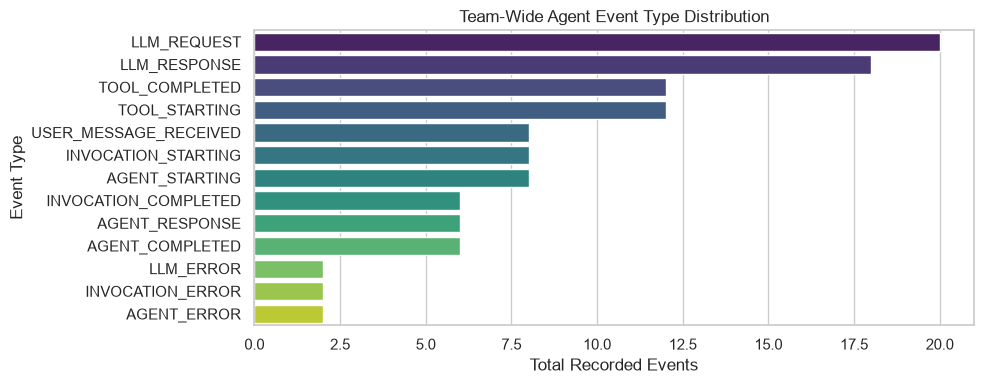

In [5]:
query_events_chart = f"""
    SELECT
        event_type AS Event_Type,
        COUNT(1) AS Count
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    GROUP BY Event_Type
    ORDER BY Count DESC
"""
df_ev_chart = bq_client.query(query_events_chart).to_dataframe()

plt.figure(figsize=(10, 4))
sns.barplot(data=df_ev_chart, x="Count", y="Event_Type", palette="viridis")
plt.title("Team-Wide Agent Event Type Distribution")
plt.xlabel("Total Recorded Events")
plt.ylabel("Event Type")
plt.tight_layout()
plt.show()
